# Step 4: Advanced Analysis
Cross-validation, model comparison, confusion matrix, ROC-AUC, and hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = pd.read_csv('../ecommerce_orders_cleaned.csv', parse_dates=['order_date'])
print('Loaded:', df.shape)
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Loaded: (500, 19)
Missing values per column:
discount_pct    5
dtype: int64


## 1. Prepare Features (with NaN handling)

In [2]:
le = LabelEncoder()
cat_cols = ['category', 'city', 'customer_gender', 'payment_method', 'product']
df_model = df.copy()

for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

df_model['target'] = df_model['order_status'].apply(
    lambda x: 1 if x in ['Delivered', 'Shipped'] else 0
)

feature_cols = [
    'customer_age', 'quantity', 'unit_price', 'discount_pct',
    'discount_amount', 'revenue', 'month',
    'category_enc', 'city_enc', 'customer_gender_enc',
    'payment_method_enc', 'product_enc'
]

X = df_model[feature_cols]
y = df_model['target']

# ----- Fix NaNs with median imputation -----
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=feature_cols)

print('After imputation — NaNs remaining:', X.isnull().sum().sum())
print('Feature shape:', X.shape)

After imputation — NaNs remaining: 0
Feature shape: (500, 12)


In [3]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 400 rows | Test: 100 rows


## 2. Cross-Validation (5-Fold)

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf, X_sc, y, cv=5, scoring='accuracy')
print('Cross-Validation Accuracy (5 folds):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {round(s*100, 2)}%')
print(f'\n  Mean : {round(cv_scores.mean()*100, 2)}%')
print(f'  Std  : {round(cv_scores.std()*100, 2)}%')

Cross-Validation Accuracy (5 folds):
  Fold 1: 89.0%
  Fold 2: 89.0%
  Fold 3: 88.0%
  Fold 4: 88.0%
  Fold 5: 88.0%

  Mean : 88.4%
  Std  : 0.49%


## 3. Model Comparison

Logistic Regression: 88.4%
Random Forest: 88.4%
Gradient Boosting: 86.8%


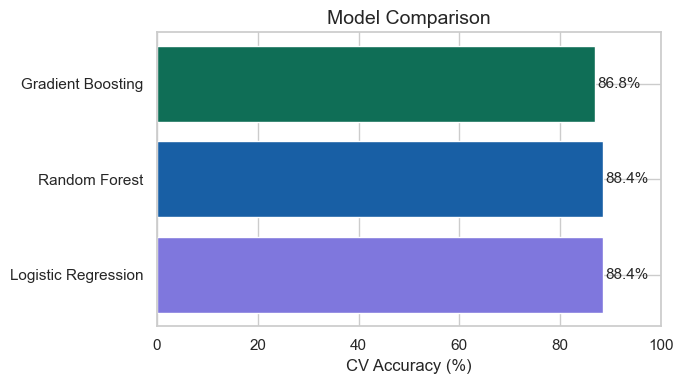

In [5]:
# Each model wrapped in a Pipeline so imputer runs inside CV too
def make_pipe(clf):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     clf)
    ])

X_raw = df_model[feature_cols]   # un-imputed raw for pipeline CV

models = {
    'Logistic Regression': make_pipe(LogisticRegression(max_iter=500)),
    'Random Forest':       make_pipe(RandomForestClassifier(n_estimators=100, random_state=42)),
    'Gradient Boosting':   make_pipe(GradientBoostingClassifier(n_estimators=100, random_state=42))
}

results = {}
for name, pipe in models.items():
    score = cross_val_score(pipe, X_raw, y, cv=5, scoring='accuracy').mean()
    results[name] = round(score * 100, 2)
    print(f'{name}: {results[name]}%')

plt.figure(figsize=(7, 4))
plt.barh(list(results.keys()), list(results.values()),
         color=['#7F77DD', '#185FA5', '#0F6E56'])
plt.xlabel('CV Accuracy (%)')
plt.title('Model Comparison', fontsize=14)
plt.xlim(0, 100)
for i, v in enumerate(results.values()):
    plt.text(v + 0.5, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Confusion Matrix

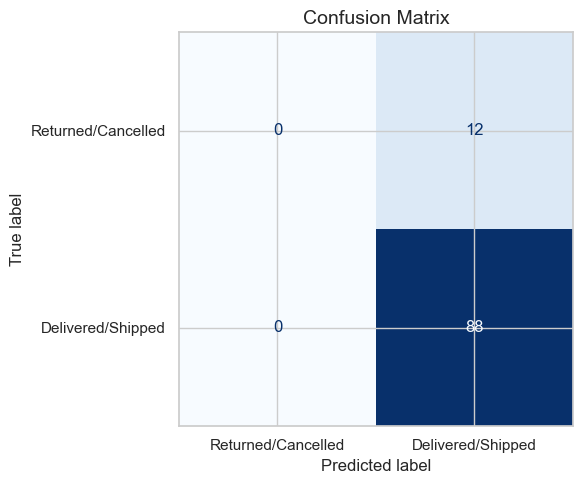

In [6]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Returned/Cancelled', 'Delivered/Shipped']
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## 5. ROC-AUC Curve

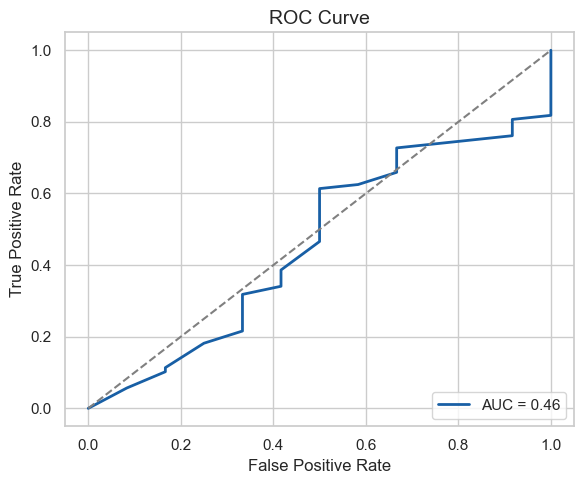

AUC Score: 0.4598


In [7]:
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#185FA5', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(f'AUC Score: {roc_auc:.4f}')

## 6. Hyperparameter Tuning (GridSearchCV)

In [8]:
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [4, 6, 8, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)
print('Best CV Accuracy:', round(grid.best_score_ * 100, 2), '%')

# Save tuned model + imputer + scaler
with open('../models/loan_model.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('All model artifacts saved to /models/')

Best Parameters: {'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Accuracy: 88.5 %
All model artifacts saved to /models/
